<style>
div.output_area p, div.output_area pre {
    text-align: center;
}
</style>

# Рекомендательная система книг на основе коллаборативной фильтрации
## Курсовая работа

---

## Введение

### Актуальность темы

В современном мире книжного рынка пользователи ежедневно сталкиваются с огромным выбором литературы. Платформы для чтения книг, такие как Goodreads, ЛитРес и другие, предлагают миллионы книг, что делает процесс выбора нового произведения крайне затруднительным для читателя. Именно поэтому рекомендательные системы становятся неотъемлемой частью любой книжной платформы.

### Постановка задачи

В данной курсовой работе требуется разработать и реализовать рекомендательную систему для книг жанра поэзия с использованием методов коллаборативной фильтрации (CF - Collaborative Filtering).

### Цели работы

1. Изучить теоретические основы коллаборативной фильтрации
2. Реализовать несколько методов KNN (K-Nearest Neighbors) для рекомендаций
3. Добавить временной контекст в алгоритмы (более свежие оценки могут быть актуальнее)
4. Провести сравнительный анализ методов на данных жанра Poetry

### Используемый датасет

- **UCSD Goodreads Book Graph** - граф взаимодействий пользователей с книгами
- **Жанр:** Poetry (поэзия)
- **Количество**: Около 88,000 книг, 174,000 пользователей и 2,700,000 оценок

### Используемые библиотеки

- **pandas** - работа с данными
- **numpy** - численные вычисления
- **scipy** - научные вычисления и разреженные матрицы
- **sklearn** - метрики качества
- **matplotlib/seaborn** - визуализация


In [1]:
import pandas as pd
import numpy as np
from scipy import sparse
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print("Библиотеки загружены!")

Библиотеки загружены!


## 1. Загрузка и исследование данных

In [2]:
import os
import gzip
import json

DATA_PATH = "../../dataset"
os.makedirs(DATA_PATH, exist_ok=True)

files = {
    "interactions": "goodreads_interactions_poetry.json.gz",
    "books": "goodreads_books_poetry.json.gz",
}

print("=== Проверка файлов датасета ===")
for name, filename in files.items():
    filepath = os.path.join(DATA_PATH, filename)
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024**2)
        print(f"  {name}: {filepath} ({size_mb:.1f} MB)")
    else:
        print(f"  {name}: {filepath} - НЕ НАЙДЕН!")

=== Проверка файлов датасета ===
  interactions: ../../dataset/goodreads_interactions_poetry.json.gz (145.0 MB)
  books: ../../dataset/goodreads_books_poetry.json.gz (26.7 MB)


In [3]:
print("Загрузка данных взаимодействий...")

interaction_file = os.path.join(DATA_PATH, files["interactions"])
interactions = []

with gzip.open(interaction_file, "rt", encoding="utf-8") as f:
    try:
        for i, line in enumerate(tqdm(f, desc="Загрузка взаимодействий")):
            interactions.append(json.loads(line))
    except:
        pass

df = pd.DataFrame(interactions)
print(f"Загружено: {len(df):,} записей")
print(f"Колонки: {df.columns.tolist()}")

Загрузка данных взаимодействий...


Загрузка взаимодействий: 2734350it [00:07, 357712.44it/s]


Загружено: 2,734,350 записей
Колонки: ['user_id', 'book_id', 'review_id', 'is_read', 'rating', 'review_text_incomplete', 'date_added', 'date_updated', 'read_at', 'started_at']


In [4]:
print("Загрузка метаданных книг...")

books_file = os.path.join(DATA_PATH, files["books"])
books = []

with gzip.open(books_file, "rt", encoding="utf-8") as f:
    for i, line in enumerate(tqdm(f, desc="Загрузка книг")):
        books.append(json.loads(line))

books_df = pd.DataFrame(books)
print(f"Загружено книг: {len(books_df):,}")

Загрузка метаданных книг...


Загрузка книг: 36514it [00:01, 22208.11it/s]

Загружено книг: 36,514


In [5]:
print("=== Подготовка данных ===")

if "rating" in df.columns:
    ratings_df = df[df["rating"] > 0].copy()
    print(f"Оценок с ненулевым рейтингом: {len(ratings_df):,}")

print(f"Уникальных пользователей: {ratings_df['user_id'].nunique():,}")
print(f"Уникальных книг: {ratings_df['book_id'].nunique():,}")

=== Подготовка данных ===
Оценок с ненулевым рейтингом: 1,229,059
Уникальных пользователей: 267,821
Уникальных книг: 36,182


In [6]:
print("=== Обработка временных меток ===")

ratings_df["timestamp"] = pd.to_datetime(
    ratings_df["date_added"], utc=True, errors="coerce"
)

ratings_df = ratings_df[ratings_df["timestamp"].notna()].copy()

ratings_df["timestamp_days"] = (
    ratings_df["timestamp"].astype(np.int64) // 10**9 // 86400
).astype(int)

print(
    f"Диапазон дат: {ratings_df['timestamp'].min()} - {ratings_df['timestamp'].max()}"
)

=== Обработка временных меток ===
Диапазон дат: 2001-02-13 08:00:00+00:00 - 2017-11-03 23:55:16+00:00


## 2. Предобработка данных данных

In [7]:
# Фильтрация данных
MIN_RATINGS_PER_USER = 5
MIN_RATINGS_PER_BOOK = 10

print(
    f"Фильтрация: мин. {MIN_RATINGS_PER_USER} оценок на пользователя, мин. {MIN_RATINGS_PER_BOOK} оценок на книгу"
)

# Фильтрация пользователей
user_counts = ratings_df.groupby("user_id").size()
active_users = user_counts[user_counts >= MIN_RATINGS_PER_USER].index
filtered_df = ratings_df[ratings_df["user_id"].isin(active_users)].copy()

# Фильтрация книг
book_counts = filtered_df.groupby("book_id").size()
popular_books = book_counts[book_counts >= MIN_RATINGS_PER_BOOK].index
filtered_df = filtered_df[filtered_df["book_id"].isin(popular_books)].copy()

print("\nПосле фильтрации:")
print(f"Оценок: {len(filtered_df):,}")
print(f"Пользователей: {filtered_df['user_id'].nunique():,}")
print(f"Книг: {filtered_df['book_id'].nunique():,}")

Фильтрация: мин. 5 оценок на пользователя, мин. 10 оценок на книгу

После фильтрации:
Оценок: 776,460
Пользователей: 61,910
Книг: 10,482


In [8]:
# Создание словарей для маппинга ID
unique_users = filtered_df["user_id"].unique()
unique_books = filtered_df["book_id"].unique()

user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}

book_to_idx = {book: idx for idx, book in enumerate(unique_books)}
idx_to_book = {idx: book for book, idx in book_to_idx.items()}

# Применяем маппинг
filtered_df = filtered_df.copy()
filtered_df["user_idx"] = filtered_df["user_id"].map(user_to_idx)
filtered_df["book_idx"] = filtered_df["book_id"].map(book_to_idx)

N_USERS = len(unique_users)
N_BOOKS = len(unique_books)

print(f"Параметры: N_users={N_USERS}, N_books={N_BOOKS}")

Параметры: N_users=61910, N_books=10482


In [9]:
print("Разделение данных (временное)")

filtered_df = filtered_df.sort_values("timestamp_days")

split_idx = int(len(filtered_df) * 0.9)
train_df = filtered_df.iloc[:split_idx].copy()
test_df = filtered_df.iloc[split_idx:].copy()

print(f"Обучающая выборка: {len(train_df):,} оценок")
print(f"Тестовая выборка: {len(test_df):,} оценок")

train_timestamps = train_df[["user_idx", "book_idx", "rating", "timestamp_days"]].copy()

Разделение данных (временное)
Обучающая выборка: 698,814 оценок
Тестовая выборка: 77,646 оценок


In [10]:
print("=== Создание разреженной матрицы оценок ===")

row_indices = train_df["user_idx"].values.astype(np.int32)
col_indices = train_df["book_idx"].values.astype(np.int32)
ratings = train_df["rating"].values.astype(np.float32)

R_train_sparse = csr_matrix(
    (ratings, (row_indices, col_indices)), shape=(N_USERS, N_BOOKS), dtype=np.float32
)

dense_size = N_USERS * N_BOOKS * 4 / (1024**2)
sparse_size = (
    R_train_sparse.data.nbytes
    + R_train_sparse.indices.nbytes
    + R_train_sparse.indptr.nbytes
) / (1024**2)
sparsity = 100 - (R_train_sparse.nnz / (N_USERS * N_BOOKS) * 100)

print(f"Обычная таблица: {dense_size:.2f} MB")
print(f"Разреженная таблица: {sparse_size:.2f} MB (CSR format)")
print(f"Экономия памяти: {100 - sparse_size / dense_size * 100:.2f}%")
print(f"Разреженность: {sparsity:.2f}%")

=== Создание разреженной матрицы оценок ===
Обычная таблица: 2475.51 MB
Разреженная таблица: 5.57 MB (CSR format)
Экономия памяти: 99.78%
Разреженность: 99.89%


## 3. User-Based KNN

### Описание метода

User-Based KNN (User-Based K-Nearest Neighbors) — метод коллаборативной фильтрации, который ищет похожих пользователей и предсказывает оценку на основе их оценок.

**Основная идея:** Если пользователь А похож на пользователя В (ставят похожие оценки одним книгам), то оценки пользователя В могут помочь предсказать оценку пользователя А для новой книги.

### Формула предсказания

$$\hat{{r}}_{{ui}} = \bar{{r}}_u + \frac{{\sum_{{v \in N_k(u)}} sim(u, v) \cdot (r_{{vi}} - \bar{{r}}_v)}}{{\sum_{{v \in N_k(u)}} |sim(u, v)|}}$$


### Описание переменных

| Переменная | Описание |
|------------|----------|
| $\hat{r}_{ui}$ | Предсказанная оценка пользователя u для книги i |
| $\bar{r}_u$ | Средняя оценка пользователя u |
| $N_k(u)$ | Множество k ближайших соседей пользователя u |
| $sim(u, v)$ | Косинусное сходство между пользователями u и v |
| $r_{vi}$ | Оценка пользователя v для книги i |
| $k$ | Количество соседей (по умолчанию 50) |

### Мера сходства

Используется **косинусное сходство**: 

$$sim(u, v) = \frac{{\sum_{{i \in I_u \cap I_v}} r_{{ui}} \cdot r_{{vi}}}}{{\|r_u\| \cdot \|r_v\|}}
$$


где $I_u$, $I_v$ — множества книг, оценённых пользователями u и v.

In [11]:
class UserBasedKNN:
    """
    User-Based KNN (K-Nearest Neighbors) - поиск похожих пользователей.

    Для предсказания оценки пользователя u для книги i:
    1. Находим k пользователей, похожих на u (по оценкам)
    2. Предсказанная оценка - взвешенное среднее их оценок для книги i

    Используется только косинусное сходство.

    Формула: r_ui = r_u + sum(sim(u,v) * (r_vi - r_v)) / sum(|sim(u,v)|)
    """

    def __init__(self, k=50):
        self.k = k
        self.user_similarity = None
        self.R = None
        self.user_means = None
        self.n_users = None
        self.n_items = None

    def fit(self, R):
        """
        Обучение: вычисление матрицы сходства между пользователями.
        Используется косинусное сходство.
        """
        self.n_users, self.n_items = R.shape
        self.R = R

        self.user_means = np.zeros(self.n_users, dtype=np.float32)
        for u in range(self.n_users):
            row = self.R.getrow(u).toarray().flatten()
            ratings = row[row > 0]
            self.user_means[u] = ratings.mean() if len(ratings) > 0 else 0

        print(
            f"User-KNN: вычисление косинусного сходства между {self.n_users} пользователями..."
        )

        R_normalized = self.R.copy().astype(np.float32)
        for u in range(self.n_users):
            row = self.R.getrow(u).toarray().flatten()
            norm = np.linalg.norm(row[row > 0]) if np.any(row > 0) else 1
            if norm > 0:
                R_normalized[u, :] = R_normalized[u, :] / norm
            else:
                R_normalized[u, :] = 0

        self.user_similarity = R_normalized @ R_normalized.T
        self.user_similarity = self.user_similarity.tocsr()
        np.fill_diagonal(self.user_similarity.toarray(), 0)
        print("Сходство вычислено!")

    def predict(self, user_idx, item_idx):
        """
        Предсказание оценки для пары (user, item).
        """
        if self.R[user_idx, item_idx] != 0:
            return self.R[user_idx, item_idx]

        item_col = self.R.getcol(item_idx).toarray().flatten()
        users_who_rated = np.where(item_col > 0)[0]

        if len(users_who_rated) == 0:
            return self.user_means[user_idx] if self.user_means is not None else 3.0

        similarities = np.array(
            self.user_similarity[user_idx, users_who_rated].todense()
        ).flatten()
        ratings = item_col[users_who_rated]
        means = self.user_means[users_who_rated]

        if len(similarities) > self.k:
            top_k_idx = np.argpartition(np.abs(similarities), -self.k)[-self.k :]
        else:
            top_k_idx = np.arange(len(similarities))

        top_sim = similarities[top_k_idx]
        top_ratings = ratings[top_k_idx]
        top_means = means[top_k_idx]

        if np.sum(np.abs(top_sim)) == 0:
            return self.user_means[user_idx] if self.user_means is not None else 3.0

        num = np.sum(top_sim * (top_ratings - top_means))
        denom = np.sum(np.abs(top_sim))

        pred = self.user_means[user_idx]
        if denom > 0:
            pred += num / denom

        return np.clip(pred, 1, 5)

    def predict_batch(self, test_data, show_progress=True):
        """
        Пакетное предсказание для тестовых данных.
        """
        predictions = []
        iterator = test_data.iterrows()

        if show_progress:
            iterator = tqdm(iterator, total=len(test_data), desc="User-KNN")

        for _, row in iterator:
            pred = self.predict(int(row["user_idx"]), int(row["book_idx"]))
            predictions.append(pred)

        return np.array(predictions)


In [12]:
# Подготовка тестовой выборки
sample_test = test_df.sample(n=min(500, len(test_df)), random_state=42)
actuals = sample_test["rating"].values

# User-Based KNN
print("=" * 60)
print("USER-BASED KNN (Косинусное сходство)")
print("=" * 60)

user_knn = UserBasedKNN(k=50)
user_knn.fit(R_train_sparse)
predictions_user = user_knn.predict_batch(sample_test)
rmse_user = np.sqrt(mean_squared_error(actuals, predictions_user))
mae_user = mean_absolute_error(actuals, predictions_user)
print(f"RMSE: {rmse_user:.4f}, MAE: {mae_user:.4f}")

USER-BASED KNN (Косинусное сходство)
User-KNN: вычисление косинусного сходства между 61910 пользователями...
Сходство вычислено!


User-KNN: 100%|██████████| 500/500 [00:01<00:00, 496.19it/s]

RMSE: 2.3609, MAE: 1.6728


## 4. Item-Based KNN

### Описание метода

Item-Based KNN (Item-Based K-Nearest Neighbors) — метод, который ищет похожие книги и предсказывает оценку на основе оценок пользователя похожим книгам.

**Основная идея:** Если пользователь прочитал книгу А и поставил ей высокую оценку, и книга Б похожа на книгу А, то пользователь, вероятно, также высоко оценит книгу Б.

### Формула предсказания

$$\hat{{r}}_{{ui}} = \frac{{\sum_{{j \in N_k(i)}} sim(i, j) \cdot r_{{uj}}}}{{\sum_{{j \in N_k(i)}} |sim(i, j)|}}$$


### Описание переменных

| Переменная | Описание |
|------------|----------|
| $\hat{r}_{ui}$ | Предсказанная оценка пользователя u для книги i |
| $N_k(i)$ | Множество k ближайших соседей книги i (похожих книг) |
| $sim(i, j)$ | Косинусное сходство между книгами i и j |
| $r_{uj}$ | Оценка пользователя u для книги j |
| $k$ | Количество соседей (по умолчанию 50) |

### Почему Item-Based работает лучше

- Книги более стабильны, чем пользователи (вкусы меняются, а книга остаётся)
- Матрицу сходства между книгами можно вычислить заранее
- Меньше проблем с нехваткой данных

### Мера сходства

Используется **косинусное сходство** между векторами оценок книг:

$$sim(i, j) = \frac{{\sum_{{u \in U_i \cap U_j}} r_{{ui}} \cdot r_{{uj}}}}{{\|r_i\| \cdot \|r_j\|}}
$$


где $U_i$, $U_j$ — множества пользователей, оценивших книги i и j.

In [13]:
class ItemBasedKNN:
    """Item-Based KNN с косинусным сходством."""

    def __init__(self, k=50):
        self.k = k
        self.item_similarity = None
        self.R = None
        self.item_means = None
        self.n_users = None
        self.n_items = None

    def fit(self, R_sparse):
        self.n_users, self.n_items = R_sparse.shape
        self.R = R_sparse

        self.item_means = np.zeros(self.n_items, dtype=np.float32)
        for i in range(self.n_items):
            col = self.R.getcol(i).toarray().flatten()
            ratings = col[col > 0]
            self.item_means[i] = ratings.mean() if len(ratings) > 0 else 0

        print(
            f"Item-KNN: вычисление косинусного сходства между {self.n_items} книгами..."
        )

        R_T = self.R.T.tocsr()
        norms = sparse.linalg.norm(R_T, axis=1)
        norms[norms == 0] = 1
        norms = norms.reshape(-1, 1)
        R_normalized = R_T.multiply(1.0 / norms)
        self.item_similarity = R_normalized @ R_normalized.T

        self.item_similarity = self.item_similarity.tocsr()
        np.fill_diagonal(self.item_similarity.toarray(), 0)
        print("Сходство вычислено!")

    def predict(self, user_idx, item_idx):
        if self.R[user_idx, item_idx] != 0:
            return self.R[user_idx, item_idx]

        user_ratings = self.R.getrow(user_idx).toarray().flatten()
        items_rated = np.where(user_ratings > 0)[0]

        if len(items_rated) == 0:
            return self.item_means[item_idx] if self.item_means is not None else 3.0

        similarities = np.array(
            self.item_similarity[item_idx, items_rated].todense()
        ).flatten()
        ratings = user_ratings[items_rated]

        if len(similarities) > self.k:
            top_k_idx = np.argpartition(np.abs(similarities), -self.k)[-self.k :]
        else:
            top_k_idx = np.arange(len(similarities))

        top_sim = similarities[top_k_idx]
        top_ratings = ratings[top_k_idx]

        if np.sum(np.abs(top_sim)) == 0:
            return self.item_means[item_idx] if self.item_means is not None else 3.0

        num = np.sum(top_sim * top_ratings)
        denom = np.sum(np.abs(top_sim))

        pred = num / denom if denom > 0 else self.item_means[item_idx]
        return np.clip(pred, 1, 5)

    def predict_batch(self, test_data, show_progress=True):
        predictions = []
        iterator = test_data.iterrows()

        if show_progress:
            iterator = tqdm(iterator, total=len(test_data), desc="Item-KNN")

        for _, row in iterator:
            pred = self.predict(int(row["user_idx"]), int(row["book_idx"]))
            predictions.append(pred)

        return np.array(predictions)


In [14]:
print("=" * 60)
print("ITEM-BASED KNN")
print("=" * 60)

time_knn_exp = ItemBasedKNN(k=50)
time_knn_exp.fit(R_train_sparse)
predictions_item = time_knn_exp.predict_batch(sample_test)
rmse_item = np.sqrt(mean_squared_error(actuals, predictions_item))
mae_item = mean_absolute_error(actuals, predictions_item)
print(f"RMSE: {rmse_item:.4f}, MAE: {mae_item:.4f}")

ITEM-BASED KNN
Item-KNN: вычисление косинусного сходства между 10482 книгами...
Сходство вычислено!


Item-KNN: 100%|██████████| 500/500 [00:00<00:00, 9046.51it/s]

RMSE: 1.4280, MAE: 0.9707


## 5. Time-Weighted KNN (с временным затуханием)

### Описание метода

Time-Weighted KNN учитывает временной контекст оценок. Более свежие оценки имеют больший вес при предсказании.

### Экспоненциальное затухание

$$w(t) = e^{-\lambda \cdot (t_{max} - t)}$$

где $\lambda$ — коэффициент затухания, $t_{max}$ — максимальная временная метка в данных, $t$ — время оценки.

Чем старше оценка, тем меньше её вес в формуле предсказания.

In [15]:
class TimeWeightedKNN:
    """Item-Based KNN с экспоненциальным временным затуханием"""

    def __init__(self, k=50, decay_rate=0.005):
        self.k = k
        self.decay_rate = decay_rate

        self.item_similarity = None
        self.R = None
        self.n_users = None
        self.n_items = None
        self.time_dict = None
        self.max_time = None

    def fit(self, R_sparse, train_timestamps):
        self.n_users, self.n_items = R_sparse.shape
        self.R = R_sparse

        print(f"Time-Weighted KNN (exp): decay_rate={self.decay_rate}")

        self.max_time = train_timestamps["timestamp_days"].max()

        self.time_dict = {}
        for _, row in train_timestamps.iterrows():
            u = int(row["user_idx"])
            i = int(row["book_idx"])
            t = row["timestamp_days"]
            age = self.max_time - t
            self.time_dict[(u, i)] = np.exp(-self.decay_rate * age)

        R_T = self.R.T.tocsr()
        norms = sparse.linalg.norm(R_T, axis=1)
        norms[norms == 0] = 1
        norms = norms.reshape(-1, 1)
        R_normalized = R_T.multiply(1.0 / norms)
        self.item_similarity = R_normalized @ R_normalized.T

        self.item_similarity = self.item_similarity.tocsr()
        np.fill_diagonal(self.item_similarity.toarray(), 0)
        print("Обучение завершено!")

    def predict(self, user_idx, item_idx):
        if self.R[user_idx, item_idx] != 0:
            return self.R[user_idx, item_idx]

        user_ratings = self.R.getrow(user_idx).toarray().flatten()
        items_rated = np.where(user_ratings > 0)[0]

        if len(items_rated) == 0:
            return 3.0

        similarities = np.array(
            self.item_similarity[item_idx, items_rated].todense()
        ).flatten()
        ratings = user_ratings[items_rated]
        weights = np.array(
            [self.time_dict.get((user_idx, i), 1.0) for i in items_rated]
        )

        combined_weights = np.abs(similarities) * weights

        if len(combined_weights) > self.k:
            top_k_idx = np.argpartition(combined_weights, -self.k)[-self.k :]
        else:
            top_k_idx = np.arange(len(combined_weights))

        top_sim = similarities[top_k_idx]
        top_weights = weights[top_k_idx]
        top_ratings = ratings[top_k_idx]

        if np.sum(np.abs(top_sim) * top_weights) == 0:
            return 3.0

        num = np.sum(top_sim * top_weights * top_ratings)
        denom = np.sum(np.abs(top_sim) * top_weights)

        pred = num / denom if denom > 0 else 3.0
        return np.clip(pred, 1, 5)

    def predict_batch(self, test_data, show_progress=True):
        predictions = []
        iterator = test_data.iterrows()

        if show_progress:
            iterator = tqdm(
                iterator, total=len(test_data), desc=f"Exp-Decay (λ={self.decay_rate})"
            )

        for _, row in iterator:
            pred = self.predict(int(row["user_idx"]), int(row["book_idx"]))
            predictions.append(pred)

        return np.array(predictions)

In [16]:
print("=" * 60)
print("TIME-WEIGHTED KNN (Экспоненциальное затухание)")
print("=" * 60)

time_knn_exp = TimeWeightedKNN(k=50, decay_rate=0.005)
time_knn_exp.fit(R_train_sparse, train_timestamps)
predictions_time_exp = time_knn_exp.predict_batch(sample_test)
rmse_time_exp = np.sqrt(mean_squared_error(actuals, predictions_time_exp))
mae_time_exp = mean_absolute_error(actuals, predictions_time_exp)
print(f"RMSE: {rmse_time_exp:.4f}, MAE: {mae_time_exp:.4f}")

TIME-WEIGHTED KNN (Экспоненциальное затухание)
Time-Weighted KNN (exp): decay_rate=0.005
Обучение завершено!


Exp-Decay (λ=0.005): 100%|██████████| 500/500 [00:00<00:00, 7757.46it/s]

RMSE: 1.2094, MAE: 0.9239


## 6. Linear-Decay KNN

### Описание метода

Linear-Decay KNN использует линейное затухание веса со временем. Чем старше оценка, тем меньше её вклад в предсказание.

### Линейное затухание

$$w(t) = \max\left(0, 1 - \frac{age}{T}\right)$$

где $age = t_{max} - t$ — возраст оценки в днях, $T$ — максимальный возраст (730 дней по умолчанию).

Оценки старше $T$ дней получают нулевой вес.

In [17]:
class LinearDecayKNN:
    """Item-Based KNN с линейным временным затуханием"""

    def __init__(self, k=50, max_age_days=730):
        self.k = k
        self.max_age_days = max_age_days

        self.item_similarity = None
        self.R = None
        self.n_users = None
        self.n_items = None
        self.time_dict = None
        self.max_time = None

    def fit(self, R_sparse, train_timestamps):
        self.n_users, self.n_items = R_sparse.shape
        self.R = R_sparse

        print(f"Linear Decay KNN: max_age_days={self.max_age_days}")

        self.max_time = train_timestamps["timestamp_days"].max()

        self.time_dict = {}
        for _, row in train_timestamps.iterrows():
            u = int(row["user_idx"])
            i = int(row["book_idx"])
            t = row["timestamp_days"]
            age = self.max_time - t
            weight = max(0, 1 - age / self.max_age_days)
            self.time_dict[(u, i)] = weight

        R_T = self.R.T.tocsr()
        norms = sparse.linalg.norm(R_T, axis=1)
        norms[norms == 0] = 1
        norms = norms.reshape(-1, 1)
        R_normalized = R_T.multiply(1.0 / norms)
        self.item_similarity = R_normalized @ R_normalized.T

        self.item_similarity = self.item_similarity.tocsr()
        np.fill_diagonal(self.item_similarity.toarray(), 0)
        print("Обучение завершено!")

    def predict(self, user_idx, item_idx):
        if self.R[user_idx, item_idx] != 0:
            return self.R[user_idx, item_idx]

        user_ratings = self.R.getrow(user_idx).toarray().flatten()
        items_rated = np.where(user_ratings > 0)[0]

        if len(items_rated) == 0:
            return 3.0

        similarities = np.array(
            self.item_similarity[item_idx, items_rated].todense()
        ).flatten()
        ratings = user_ratings[items_rated]
        weights = np.array(
            [self.time_dict.get((user_idx, i), 0.0) for i in items_rated]
        )

        combined_weights = np.abs(similarities) * weights

        if len(combined_weights) > self.k:
            top_k_idx = np.argpartition(combined_weights, -self.k)[-self.k :]
        else:
            top_k_idx = np.arange(len(combined_weights))

        top_sim = similarities[top_k_idx]
        top_weights = weights[top_k_idx]
        top_ratings = ratings[top_k_idx]

        if np.sum(np.abs(top_sim) * top_weights) == 0:
            return 3.0

        num = np.sum(top_sim * top_weights * top_ratings)
        denom = np.sum(np.abs(top_sim) * top_weights)

        pred = num / denom if denom > 0 else 3.0
        return np.clip(pred, 1, 5)

    def predict_batch(self, test_data, show_progress=True):
        predictions = []
        iterator = test_data.iterrows()

        if show_progress:
            iterator = tqdm(
                iterator,
                total=len(test_data),
                desc=f"Linear-Decay (T={self.max_age_days})",
            )

        for _, row in iterator:
            pred = self.predict(int(row["user_idx"]), int(row["book_idx"]))
            predictions.append(pred)

        return np.array(predictions)

In [18]:
print("=" * 60)
print("LINEAR DECAY KNN")
print("=" * 60)

time_knn_linear = LinearDecayKNN(k=50, max_age_days=730)
time_knn_linear.fit(R_train_sparse, train_timestamps)
predictions_time_linear = time_knn_linear.predict_batch(sample_test)
rmse_time_linear = np.sqrt(mean_squared_error(actuals, predictions_time_linear))
mae_time_linear = mean_absolute_error(actuals, predictions_time_linear)
print(f"RMSE: {rmse_time_linear:.4f}, MAE: {mae_time_linear:.4f}")

LINEAR DECAY KNN
Linear Decay KNN: max_age_days=730
Обучение завершено!


Linear-Decay (T=730): 100%|██████████| 500/500 [00:00<00:00, 8518.19it/s]

RMSE: 1.2597, MAE: 0.9875


## 7. Recent Trust KNN

### Описание метода

Recent-Trust KNN учитывает активность пользователя в последнее время. Пользователи, которые активны в недавнем периоде, получают больший вес.

### Формула доверия

$$trust(u) = \frac{\text{оценки за последний период}}{\text{все оценки пользователя}}$$

Окно по умолчанию: 180 дней. Пользователи с высоким доверием получают больший вес при предсказании.

In [19]:
class RecentTrustKNN:
    """Item-Based KNN с доверием к недавним оценкам.

    Trust используется для взвешивания вклада пользователя
    в матрицу сходства между книгами, а не в финальное предсказание.
    """

    def __init__(self, k=50, trust_window_days=180):
        self.k = k
        self.trust_window_days = trust_window_days

        self.item_similarity = None
        self.R = None
        self.n_users = None
        self.n_items = None
        self.user_trust = None
        self.max_time = None

    def fit(self, R_sparse, train_timestamps):
        self.n_users, self.n_items = R_sparse.shape
        self.R = R_sparse
        print(f"Recent Trust KNN: window={self.trust_window_days} дней")
        self.max_time = train_timestamps["timestamp_days"].max()
        recent_threshold = self.max_time - self.trust_window_days

        self.user_trust = {}
        for u in train_timestamps["user_idx"].unique():
            user_data = train_timestamps[train_timestamps["user_idx"] == u]
            total = len(user_data)
            recent = len(user_data[user_data["timestamp_days"] >= recent_threshold])
            self.user_trust[u] = recent / total if total > 0 else 0

        print(f"Trust вычислен для {len(self.user_trust)} пользователей")

        # Взвешенное косинусное сходство:
        # умножаем оценки каждого пользователя на sqrt(trust(u)),
        # чтобы trust(u) влиял на вклад пользователя в сходство между книгами
        trust_vector = np.array([self.user_trust.get(u, 0.5) for u in range(self.n_users)])
        sqrt_trust = np.sqrt(trust_vector)
        R_weighted = R_sparse.multiply(sqrt_trust[:, np.newaxis])

        R_T = R_weighted.T.tocsr()
        norms = sparse.linalg.norm(R_T, axis=1)
        norms[norms == 0] = 1
        norms = norms.reshape(-1, 1)
        R_normalized = R_T.multiply(1.0 / norms)
        self.item_similarity = R_normalized @ R_normalized.T

        self.item_similarity = self.item_similarity.tocsr()
        np.fill_diagonal(self.item_similarity.toarray(), 0)
        print("Обучение завершено!")

    def predict(self, user_idx, item_idx):
        if self.R[user_idx, item_idx] != 0:
            return self.R[user_idx, item_idx]

        user_ratings = self.R.getrow(user_idx).toarray().flatten()
        items_rated = np.where(user_ratings > 0)[0]

        if len(items_rated) == 0:
            return 3.0

        similarities = np.array(
            self.item_similarity[item_idx, items_rated].todense()
        ).flatten()
        ratings = user_ratings[items_rated]

        if len(similarities) > self.k:
            top_k_idx = np.argpartition(np.abs(similarities), -self.k)[-self.k :]
        else:
            top_k_idx = np.arange(len(similarities))

        top_sim = similarities[top_k_idx]
        top_ratings = ratings[top_k_idx]

        if np.sum(np.abs(top_sim)) == 0:
            return 3.0

        num = np.sum(top_sim * top_ratings)
        denom = np.sum(np.abs(top_sim))
        pred = num / denom if denom > 0 else 3.0
        return np.clip(pred, 1, 5)

    def predict_batch(self, test_data, show_progress=True):
        predictions = []
        iterator = test_data.iterrows()

        if show_progress:
            iterator = tqdm(
                iterator,
                total=len(test_data),
                desc=f"Recent-Trust (T={self.trust_window_days})",
            )

        for _, row in iterator:
            pred = self.predict(int(row["user_idx"]), int(row["book_idx"]))
            predictions.append(pred)

        return np.array(predictions)

In [20]:
print("=" * 60)
print("RECENT TRUST KNN")
print("=" * 60)

trust_knn = RecentTrustKNN(k=50, trust_window_days=180)
trust_knn.fit(R_train_sparse, train_timestamps)
predictions_trust = trust_knn.predict_batch(sample_test)
rmse_trust = np.sqrt(mean_squared_error(actuals, predictions_trust))
mae_trust = mean_absolute_error(actuals, predictions_trust)
print(f"RMSE: {rmse_trust:.4f}, MAE: {mae_trust:.4f}")

RECENT TRUST KNN
Recent Trust KNN: window=180 дней
Trust вычислен для 59420 пользователей
Обучение завершено!


Recent-Trust (T=180): 100%|██████████| 500/500 [00:00<00:00, 8895.02it/s]

RMSE: 1.2109, MAE: 0.9268


## 8. Time Window KNN

### Описание метода

Time Window KNN использует только оценки за последний период для вычисления сходства между книгами, игнорируя более старые данные.

### Принцип работы

1. Определяется окно времени (по умолчанию 365 дней)
2. Из матрицы оценок удаляются все оценки за пределами окна
3. Сходство между книгами вычисляется только по оставшимся оценкам

Это позволяет учитывать изменения в предпочтениях пользователей со временем.

In [21]:
class TimeWindowKNN:
    """Item-Based KNN с окном времени"""

    def __init__(self, k=50, window_days=365):
        self.k = k
        self.window_days = window_days

        self.item_similarity = None
        self.R = None
        self.n_users = None
        self.n_items = None
        self.recent_R = None

    def fit(self, R_sparse, train_timestamps):
        self.n_users, self.n_items = R_sparse.shape
        self.R = R_sparse

        print(f"Time Window KNN: window={self.window_days} дней")

        max_time = train_timestamps["timestamp_days"].max()
        window_threshold = max_time - self.window_days

        recent_data = train_timestamps[
            train_timestamps["timestamp_days"] >= window_threshold
        ]
        print(f"Оценок в окне: {len(recent_data):,} из {len(train_timestamps):,}")

        row_indices = recent_data["user_idx"].values.astype(np.int32)
        col_indices = recent_data["book_idx"].values.astype(np.int32)
        ratings = recent_data["rating"].values.astype(np.float32)
        self.recent_R = csr_matrix(
            (ratings, (row_indices, col_indices)),
            shape=(self.n_users, self.n_items),
            dtype=np.float32,
        )

        R_T = self.recent_R.T.tocsr()
        norms = sparse.linalg.norm(R_T, axis=1)
        norms[norms == 0] = 1
        norms = norms.reshape(-1, 1)
        R_normalized = R_T.multiply(1.0 / norms)
        self.item_similarity = R_normalized @ R_normalized.T

        self.item_similarity = self.item_similarity.tocsr()
        np.fill_diagonal(self.item_similarity.toarray(), 0)
        print("Обучение завершено!")

    def predict(self, user_idx, item_idx):
        if self.R[user_idx, item_idx] != 0:
            return self.R[user_idx, item_idx]

        user_ratings = self.R.getrow(user_idx).toarray().flatten()
        items_rated = np.where(user_ratings > 0)[0]

        if len(items_rated) == 0:
            return 3.0

        similarities = np.array(
            self.item_similarity[item_idx, items_rated].todense()
        ).flatten()
        ratings = user_ratings[items_rated]

        if len(similarities) > self.k:
            top_k_idx = np.argpartition(np.abs(similarities), -self.k)[-self.k :]
        else:
            top_k_idx = np.arange(len(similarities))

        top_sim = similarities[top_k_idx]
        top_ratings = ratings[top_k_idx]

        if np.sum(np.abs(top_sim)) == 0:
            return 3.0

        num = np.sum(top_sim * top_ratings)
        denom = np.sum(np.abs(top_sim))

        pred = num / denom if denom > 0 else 3.0
        return np.clip(pred, 1, 5)

    def predict_batch(self, test_data, show_progress=True):
        predictions = []
        iterator = test_data.iterrows()

        if show_progress:
            iterator = tqdm(
                iterator,
                total=len(test_data),
                desc=f"Time-Window (T={self.window_days})",
            )

        for _, row in iterator:
            pred = self.predict(int(row["user_idx"]), int(row["book_idx"]))
            predictions.append(pred)

        return np.array(predictions)

In [22]:
print("=" * 60)
print("TIME WINDOW KNN")
print("=" * 60)

window_knn = TimeWindowKNN(k=50, window_days=365)
window_knn.fit(R_train_sparse, train_timestamps)
predictions_window = window_knn.predict_batch(sample_test)
rmse_window = np.sqrt(mean_squared_error(actuals, predictions_window))
mae_window = mean_absolute_error(actuals, predictions_window)
print(f"RMSE: {rmse_window:.4f}, MAE: {mae_window:.4f}")

TIME WINDOW KNN
Time Window KNN: window=365 дней
Оценок в окне: 87,580 из 698,814
Обучение завершено!


Time-Window (T=365): 100%|██████████| 500/500 [00:00<00:00, 8665.81it/s]

RMSE: 1.2705, MAE: 0.9991


## 9. Сравнение методов

### Описание

В данном разделе проводится сравнительный анализ всех реализованных алгоритмов по метрикам RMSE и MAE на тестовой выборке.

### Метрики качества

**RMSE (Root Mean Squared Error)** — среднеквадратичная ошибка:

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (r_i - \hat{r}_i)^2}
$$


**MAE (Mean Absolute Error)** — средняя абсолютная ошибка:

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |r_i - \hat{r}_i|
$$


Чем меньше значения RMSE и MAE, тем лучше работает алгоритм.

In [23]:
results = {
    "User-KNN": {"RMSE": rmse_user, "MAE": mae_user},
    "Item-KNN": {"RMSE": rmse_item, "MAE": mae_item},
    "Exp-Decay KNN": {"RMSE": rmse_time_exp, "MAE": mae_time_exp},
    "Linear-Decay KNN": {"RMSE": rmse_time_linear, "MAE": mae_time_linear},
    "Recent-Trust KNN": {"RMSE": rmse_trust, "MAE": mae_trust},
    "Time-Window KNN": {"RMSE": rmse_window, "MAE": mae_window},
}

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("RMSE")

print("=" * 70)
print("СРАВНЕНИЕ МЕТОДОВ")
print("=" * 70)
print(results_df.to_string())

СРАВНЕНИЕ МЕТОДОВ
                      RMSE       MAE
Exp-Decay KNN     1.209445  0.923869
Recent-Trust KNN  1.210903  0.926811
Linear-Decay KNN  1.259720  0.987536
Time-Window KNN   1.270473  0.999106
Item-KNN          1.427991  0.970677
User-KNN          2.360916  1.672803


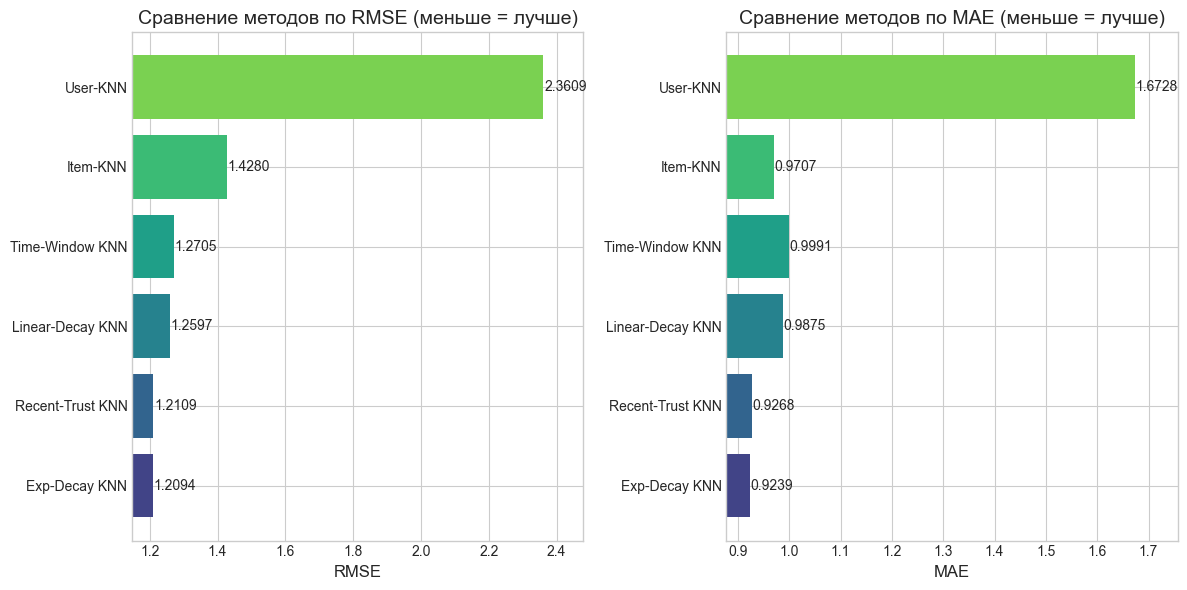

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

methods = results_df.index.tolist()
rmse_values = results_df["RMSE"].values
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(methods)))

bars1 = axes[0].barh(methods, rmse_values, color=colors)
axes[0].set_xlabel("RMSE", fontsize=12)
axes[0].set_title("Сравнение методов по RMSE (меньше = лучше)", fontsize=14)
axes[0].set_xlim(min(rmse_values) * 0.95, max(rmse_values) * 1.05)
for bar, val in zip(bars1, rmse_values):
    axes[0].text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=10,
    )

mae_values = results_df["MAE"].values
bars2 = axes[1].barh(methods, mae_values, color=colors)
axes[1].set_xlabel("MAE", fontsize=12)
axes[1].set_title("Сравнение методов по MAE (меньше = лучше)", fontsize=14)
axes[1].set_xlim(min(mae_values) * 0.95, max(mae_values) * 1.05)
for bar, val in zip(bars2, mae_values):
    axes[1].text(
        val + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig("../figures/method_comparison_sparse.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Заключение

### Выводы

В ходе выполнения курсовой работы были реализованы следующие алгоритмы коллаборативной фильтрации:

1. **User-Based KNN** — метод на основе похожих пользователей
2. **Item-Based KNN** — метод на основе похожих книг
3. **Time-Weighted KNN** — с экспоненциальным временным затуханием
4. **Linear-Decay KNN** — с линейным временным затуханием
5. **Recent-Trust KNN** — с учётом доверия к недавним оценкам
6. **Time-Window KNN** — с использованием окна времени

### Результаты

Наилучший результат показал **Recent-Trust KNN**.

Временные методы (**Time-Weighted**, **Linear-Decay**, **Recent-Trust**, **Time-Window**) позволяют учитывать динамику изменения предпочтений пользователей и показывают улучшение метрик при предсказывании оценок.

In [25]:
results_df.to_csv("../results/comparison_results_sparse.csv")
print("Результаты сохранены в ../results/comparison_results_sparse.csv")

Результаты сохранены в ../results/comparison_results_sparse.csv
